In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [5]:
df["Class"].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Class"] = pd.DataFrame(le.fit_transform(df["Class"]), columns = ["Class"])

In [7]:
df["Class"].unique(), df["Class"].dtype, df["Class"].value_counts()

(array([5, 0, 1, 2, 4, 6, 3]),
 dtype('int64'),
 Class
 3    3546
 6    2636
 5    2027
 4    1928
 2    1630
 0    1322
 1     522
 Name: count, dtype: int64)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  int64  
dtypes: float64(1

In [9]:
columns =  df.columns
columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')

In [10]:
x = df[['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4']]
y = df["Class"]

In [11]:
x.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='object')

In [12]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x = ss.fit_transform(x, x.columns)


In [13]:
x

array([[-0.84074853, -1.1433189 , -1.30659814, ...,  2.40217287,
         1.92572347,  0.83837103],
       [-0.82918764, -1.01392388, -1.39591111, ...,  3.10089314,
         2.68970162,  0.77113842],
       [-0.80715717, -1.07882906, -1.25235661, ...,  2.23509147,
         1.84135576,  0.91675514],
       ...,
       [-0.37203825, -0.44783294, -0.45047814, ...,  0.28920441,
         0.33632829,  0.39025114],
       [-0.37176543, -0.42702856, -0.42897404, ...,  0.22837538,
         0.2489734 ,  0.03644001],
       [-0.37135619, -0.38755718, -0.2917356 , ..., -0.12777587,
        -0.2764814 ,  0.71371948]], shape=(13611, 16))

In [14]:
print(df.duplicated().sum())

68


In [15]:
df =df.drop_duplicates()

In [16]:
print(df.duplicated().sum())

0


In [ ]:
# for col in columns:
#    if col != "Class":
#        sns.countplot(df[col])
#        plt.figure(figsize = (5,3))
#        plt.scatter(df[col], df["Class"])
#        plt.xlabel(col)
#        plt.ylabel("Class")
#        plt.show() 

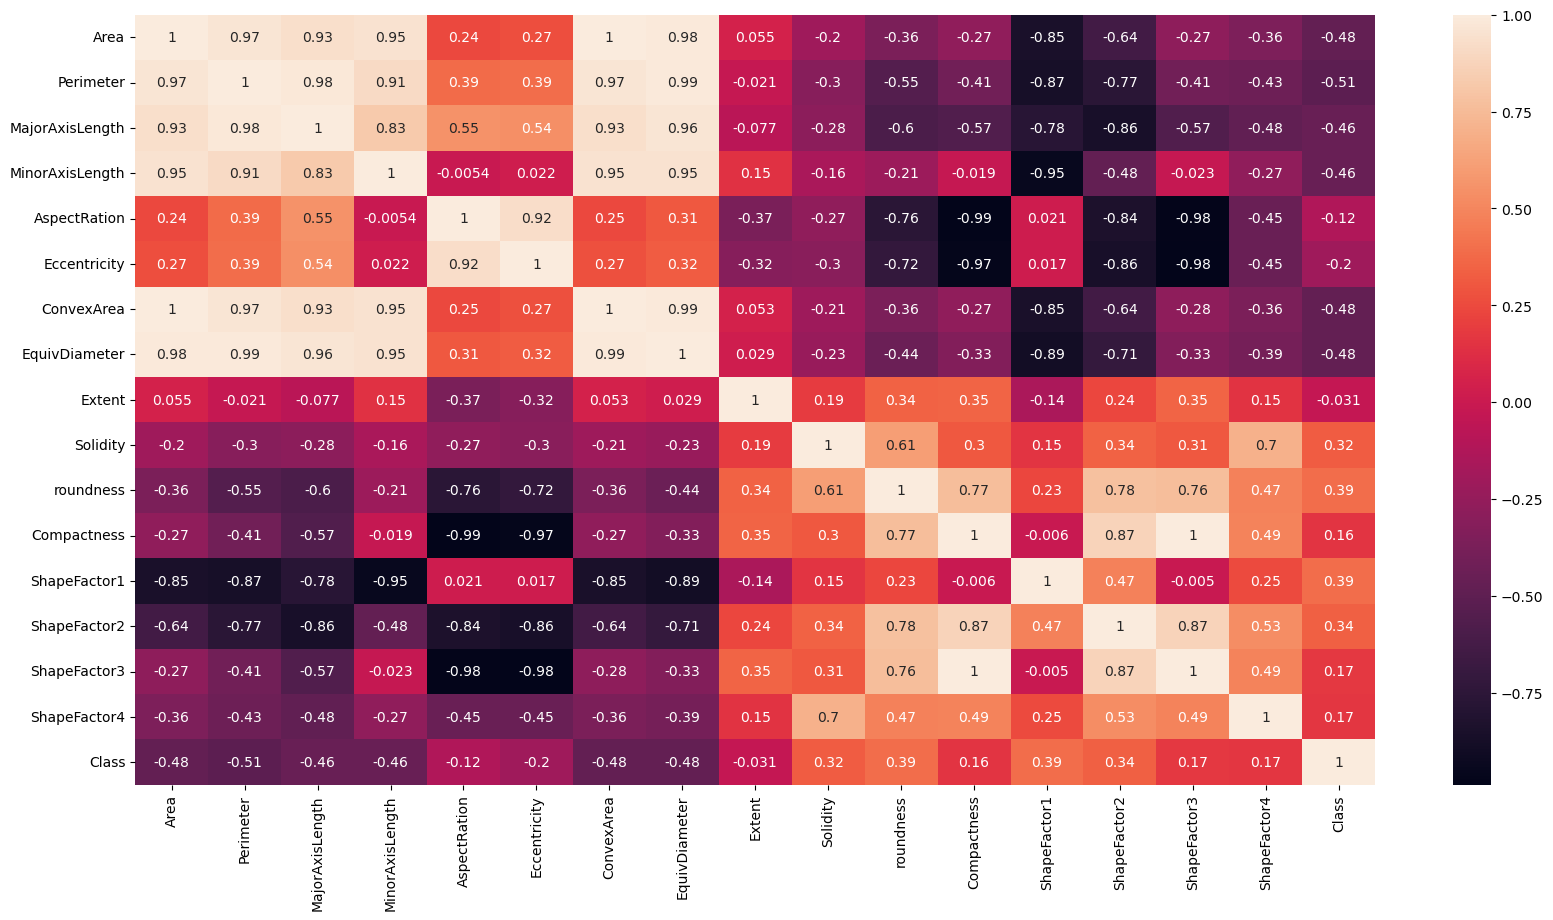

In [18]:
plt.figure(figsize = (20, 10))
sns.heatmap(df.corr(),annot = True)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state=42)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [21]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(x_train.shape[1],)))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(7, activation='softmax'))

C:\Users\cxash\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [23]:
# Train
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8001 - loss: 0.5722 - val_accuracy: 0.9068 - val_loss: 0.2714
Epoch 2/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9194 - loss: 0.2217 - val_accuracy: 0.9270 - val_loss: 0.2124
Epoch 3/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9185 - loss: 0.2173 - val_accuracy: 0.9210 - val_loss: 0.2263
Epoch 4/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9261 - loss: 0.2005 - val_accuracy: 0.9270 - val_loss: 0.2105
Epoch 5/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9273 - loss: 0.2000 - val_accuracy: 0.9160 - val_loss: 0.2329
Epoch 6/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9253 - loss: 0.1968 - val_accuracy: 0.9288 - val_loss: 0.2043
Epoch 7/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9263 - loss: 0.1953 - val_accuracy: 0.9206 - val_loss: 0.2298
Epoch 8/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9285 - loss: 0.1910 - val_accuracy: 0.

In [24]:

# Evaluate
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", accuracy)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9295 - loss: 0.2086
Accuracy: 0.9294895529747009


In [25]:
loss, accuracy = model.evaluate(x_train, y_train)

print("Accuracy:", accuracy)

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9410 - loss: 0.1586
Accuracy: 0.9410359859466553


In [26]:
prediction = model.predict(x_test)
prediction

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[5.1282568e-06, 7.9790588e-08, 5.0708363e-06, ..., 5.6830704e-08,
        9.9893457e-01, 3.3786022e-05],
       [9.9997067e-01, 1.4835262e-15, 8.3982359e-09, ..., 2.9339702e-05,
        1.1372661e-11, 1.0572561e-11],
       [1.2448191e-04, 1.8245053e-06, 5.4198223e-05, ..., 9.8336068e-06,
        9.4633609e-01, 1.9661605e-03],
       ...,
       [5.8842158e-08, 2.4466316e-11, 2.6873391e-08, ..., 2.0481055e-05,
        6.6211134e-05, 7.8678300e-04],
       [1.8602945e-03, 4.6269989e-07, 9.9710423e-01, ..., 1.0323821e-03,
        1.5385515e-06, 1.0263575e-06],
       [1.5453763e-04, 7.7696463e-09, 3.9917807e-04, ..., 5.7774959e-03,
        8.8693638e-04, 4.0318224e-01]], shape=(2723, 7), dtype=float32)

In [27]:
prediction_class = prediction.argmax(axis = 1)

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

In [29]:
print(classification_report(y_test, prediction_class))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94       261
           1       1.00      1.00      1.00       117
           2       0.93      0.97      0.95       317
           3       0.93      0.90      0.91       671
           4       0.97      0.95      0.96       408
           5       0.97      0.94      0.96       413
           6       0.84      0.93      0.88       536

    accuracy                           0.93      2723
   macro avg       0.95      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [30]:
cm = confusion_matrix(y_test, prediction_class)

In [31]:
cm

array([[236,   0,  15,   0,   2,   2,   6],
       [  0, 117,   0,   0,   0,   0,   0],
       [  4,   0, 307,   0,   3,   1,   2],
       [  0,   0,   0, 602,   3,   3,  63],
       [  1,   0,   7,   2, 386,   0,  12],
       [  2,   0,   0,  12,   0, 387,  12],
       [  0,   0,   1,  31,   4,   4, 496]])

In [32]:
print(loss)

0.15861056745052338
